\https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet

In [169]:
#インポート
import os
import cv2
import csv
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torchvision

import random

In [137]:
#シード値固定
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [138]:
#データをダウンロード
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

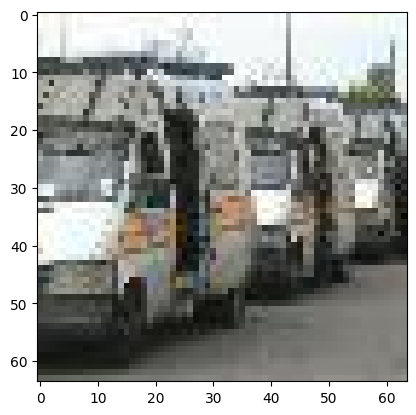

In [139]:
#データセットをつくる
seed_everything(0)

image_paths_train = []
DATA_DIR_train = f"{path}/tiny-imagenet-200/train" #DATA_DIRに学習用データ(train)を入れる
for D in os.listdir(DATA_DIR_train): #os.listdirでDATA_DIR(train)の全てのフォルダ名を取得
  image_dir = f"{DATA_DIR_train}/{D}/images" #image_dirにimagesフォルダのパスを入れる
  image_paths_train.extend([f"{image_dir}/{IP}" for IP in os.listdir(image_dir)]) #image_paths配列にimagesフォルダのパスファイルを入れる

datas = [] #画像とラベルを格納するリスト
for img_path in image_paths_train: #画像のパスでまわす
    class_id = img_path.split("/")[-3] #クラスのidをclass_idにいれる
    datas.append({"image_path": img_path, "label": class_id}) ##画像のパスとラベルを辞書にして一つにまとめる

idx = np.random.randint(0, len(datas)) #0～データ数で乱数を生成してidxに入れる
image = Image.open(datas[idx]["image_path"]) #ランダムに選ばれた画像と画像のパスを開いてimageに入れる

fig = plt.figure() #図を作成
ax = fig.add_subplot() #描画エリアを作成
ax.imshow(image) #画像を表示

In [140]:
# クラス定義（Tiny ImageNet）
seed_everything(0)

WNID_FILE = f"{path}/tiny-imagenet-200/wnids.txt" #クラスの定義
with open(WNID_FILE, "r") as f: #ファイルを読み込む
    wnids = [line.strip() for line in f] #開業をなくしてリストに保存

category_to_index = {wnid: i for i, wnid in enumerate(wnids)} #クラスIDと数値ラベルを作成
index_to_category = {i: wnid for wnid, i in category_to_index.items()} #上の逆バージョン

# データ作成
x = [] #入力データ
t = [] #教師ラベル

for D in datas:
    x.append(D["image_path"]) #画像ファイルのパスをxに追加
    t.append(category_to_index[D["label"]]) #クラスIDを数値ラベルにしてtに追加

# train / test 分割
tmp = list(zip(x, t)) #画像パスとラベルをペアにする
train_tmp, test_tmp = train_test_split(tmp, test_size=0.1, random_state=42) #データを9:1に分割

train_x, train_t = zip(*train_tmp) #入力データとラベルデータに分ける
test_x, test_t = zip(*test_tmp) ##入力データとラベルデータに分ける

Text(0.5, 1.0, 'preprocessed')

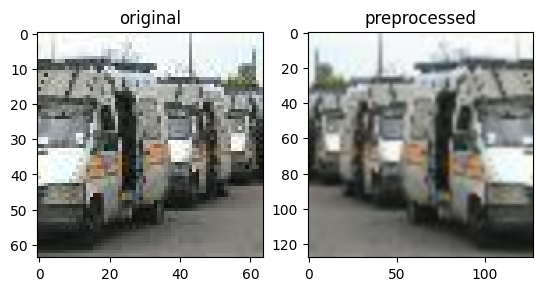

In [141]:
# 画像の前処理関数
seed_everything(0)

image_preprocessor = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.RandomCrop(128),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(), #PIL画像→PyTorch Tensorに変換
])

image = Image.open(datas[idx]["image_path"]) #画像をランダムに選ぶ
preprocessed_image = image_preprocessor(image) #前処理を全てに適応する

fig = plt.figure() #図を作成
ax = fig.add_subplot(1, 2, 1) #1行2列の左側に表示
ax.imshow(image) #元画像を表示
ax.set_title("original") #タイトルを表示

ax = fig.add_subplot(1, 2, 2) #右側に表示
ax.imshow(preprocessed_image.permute(1, 2, 0)) #次元の並び替えを行っている
ax.set_title("preprocessed") #タイトルを表示

In [142]:
# 学習のパラメータ
EPOCHS = 300
BATCH_SIZE =  512

In [143]:
seed_everything(0)
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, teacher_signals, transform):

        self.image_paths = image_paths
        self.teacher_signals = teacher_signals
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open( self.image_paths[idx] ).convert('RGB')
        input = self.transform(image)

        teacher_signal = self.teacher_signals[idx]
        teacher_signal = torch.tensor(teacher_signal, dtype=torch.long)

        return input, teacher_signal

def collate_fn(batch):
    inputs = torch.stack( [B[0] for B in batch] )
    teacher_signals = torch.stack( [B[1] for B in batch] )

    return inputs, teacher_signals

train_dataset = MyDataset(image_paths = train_x,
                          teacher_signals = train_t,
                          transform = image_preprocessor)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    collate_fn = collate_fn,
    num_workers = 2,
    shuffle = True,
    pin_memory = True,
    persistent_workers = True,
)

image_preprocessor = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.RandomCrop(128),
    torchvision.transforms.ToTensor(),
])
test_dataset = MyDataset(image_paths = test_x,
                          teacher_signals = test_t,
                          transform = image_preprocessor)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    collate_fn = collate_fn,
    num_workers = 2,
    pin_memory = True,
    persistent_workers = True,
)

I, T = next(iter(train_dataloader))
I.shape, T.shape

(torch.Size([512, 3, 128, 128]), torch.Size([512]))

In [144]:
seed_everything(0)
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 64)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(64, 200)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y

seed_everything(0)
model = MyModel()
model(I[:1])

tensor([[-0.1781, -0.0165,  0.0649, -0.0342,  0.0074,  0.0731,  0.0770,  0.2737,
          0.1320, -0.0006,  0.1524, -0.0628,  0.0729,  0.1703, -0.0927,  0.0199,
         -0.0681,  0.0481,  0.0831,  0.0237, -0.1061, -0.0512,  0.0851,  0.1307,
          0.1462, -0.0132,  0.0556,  0.1276,  0.1267, -0.1816, -0.0276, -0.0353,
         -0.1024, -0.0122,  0.0981,  0.1539, -0.0256, -0.0178, -0.1572, -0.0245,
         -0.0200, -0.3514, -0.0627, -0.0266, -0.1187,  0.1295,  0.1298,  0.1430,
          0.0972,  0.0189,  0.1392, -0.1699, -0.0287, -0.1035,  0.2041, -0.0983,
          0.0815,  0.0320, -0.0878,  0.2176, -0.1612, -0.0850,  0.0524, -0.1168,
         -0.0960,  0.0166,  0.0071, -0.0963,  0.0074, -0.1205,  0.0281, -0.0550,
          0.0175,  0.1376,  0.0153, -0.0948, -0.0211,  0.0475,  0.0924, -0.0265,
         -0.0653, -0.0873,  0.1132, -0.1309, -0.0087,  0.1054, -0.1407, -0.0358,
          0.0017, -0.0485, -0.0379,  0.0894, -0.0349, -0.1795, -0.1490,  0.1478,
         -0.0534, -0.1413, -

In [145]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [146]:
#学習の関数
seed_everything(0)
def loss_func(Y, T):
    E = ((-1.0 * T * torch.log(Y + 1e-6))).sum(dim=1).mean()
    return E

def accuracy_func(Y, T):
    Y = Y.argmax(dim=1)
    A = (Y == T).float().mean()
    return A

def iteration(X_batch, T_batch, model, optimizer = None):
    X_batch = X_batch.to(device)
    T_batch = T_batch.to(device)

    # 学習する場合
    if optimizer is not None:
        optimizer.zero_grad()
        Y_batch = model(X_batch)
        E_batch = loss_func(Y_batch, T_batch)
        E_batch.backward()
        optimizer.step()

    # 学習しない場合
    else:
        with torch.no_grad():
            Y_batch = model(X_batch)
            E_batch = loss_func(Y_batch, T_batch)

    A_batch = accuracy_func(Y_batch, T_batch)

    return E_batch.item(), A_batch.item()

def epoch(dataloader, model, optimizer = None):

    E = 0
    A = 0
    total_data = 0

    pb = tqdm(dataloader)
    for X_batch, T_batch in pb:

        E_batch, A_batch = iteration(X_batch, T_batch, model, optimizer)

        # ミニバッチの平均になっている誤差と精度を総和に戻す
        E += E_batch * len(X_batch)
        A += A_batch * len(X_batch)
        total_data += len(X_batch)

        pb.set_postfix({"loss": E / total_data,
                        "accuracy": A / total_data})

    # 全データでの平均の誤差と精度
    E /= total_data
    A /= total_data

    return E, A

In [147]:
#SGD(lr=0.1)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
A_SGD_train_loss_history = list()
A_SGD_train_accuracy_history = list()
A_SGD_test_loss_history = list()
A_SGD_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
A_SGD_train_loss_history.append(E)
A_SGD_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
A_SGD_test_loss_history.append(E)
A_SGD_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    A_SGD_train_loss_history.append(E)
    A_SGD_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    A_SGD_test_loss_history.append(E)
    A_SGD_test_accuracy_history.append(A)

    if A == max(A_SGD_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

  0%|          | 0/176 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:03<00:00,  5.61it/s, loss=5.31, accuracy=0.0038] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.96it/s, loss=5.17, accuracy=0.0202]


epoch; 2


...

100%|██████████| 20/20 [00:02<00:00,  9.05it/s, loss=3.22, accuracy=0.288]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  9.14it/s, loss=3.28, accuracy=0.286]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.53it/s, loss=3.27, accuracy=0.277]


In [148]:
#SGD-Momentum(lr=0.1)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
A_Momentum_train_loss_history = list()
A_Momentum_train_accuracy_history = list()
A_Momentum_test_loss_history = list()
A_Momentum_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
A_Momentum_train_loss_history.append(E)
A_Momentum_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
A_Momentum_test_loss_history.append(E)
A_Momentum_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    A_Momentum_train_loss_history.append(E)
    A_Momentum_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    A_Momentum_test_loss_history.append(E)
    A_Momentum_test_accuracy_history.append(A)

    if A == max(A_Momentum_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  9.00it/s, loss=5.31, accuracy=0.0051] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.88it/s, loss=5.91, accuracy=0.022] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.85it/s, loss=4.41, accuracy=0.0783]


...

100%|██████████| 20/20 [00:02<00:00,  8.57it/s, loss=2.99, accuracy=0.342]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.44it/s, loss=2.97, accuracy=0.343]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.47it/s, loss=2.98, accuracy=0.342]


In [149]:
#RMSprop(lr=0.1)
model = MyModel().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.1, alpha = 0.99, eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
A_RMSporp_train_loss_history = list()
A_RMSporp_train_accuracy_history = list()
A_RMSporp_test_loss_history = list()
A_RMSporp_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
A_RMSporp_train_loss_history.append(E)
A_RMSporp_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
A_RMSporp_test_loss_history.append(E)
A_RMSporp_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    A_RMSporp_train_loss_history.append(E)
    A_RMSporp_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    A_RMSporp_test_loss_history.append(E)
    A_RMSporp_test_accuracy_history.append(A)

    if A == max(A_RMSporp_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.53it/s, loss=5.31, accuracy=0.0059] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.61it/s, loss=5.16, accuracy=0.0188]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=5.03, accuracy=0.0218]


...

100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=4.15, accuracy=0.102]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.70it/s, loss=4.31, accuracy=0.0838]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.65it/s, loss=4.16, accuracy=0.0948]


In [150]:
#Adam(lr=0.1)
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.1, betas = (0.9, 0.999), eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
A_Adam_train_loss_history = list()
A_Adam_train_accuracy_history = list()
A_Adam_test_loss_history = list()
A_Adam_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
A_Adam_train_loss_history.append(E)
A_Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
A_Adam_test_loss_history.append(E)
A_Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    A_Adam_train_loss_history.append(E)
    A_Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    A_Adam_test_loss_history.append(E)
    A_Adam_test_accuracy_history.append(A)

    if A == max(A_Adam_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.71it/s, loss=5.3, accuracy=0.0067]  


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.75it/s, loss=5.18, accuracy=0.0124]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.74it/s, loss=4.99, accuracy=0.0211]


...

100%|██████████| 20/20 [00:02<00:00,  8.69it/s, loss=4.59, accuracy=0.0344]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.94it/s, loss=4.55, accuracy=0.034] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.72it/s, loss=4.57, accuracy=0.0336]


In [151]:
#SGD(lr=0.01)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
B_SGD_train_loss_history = list()
B_SGD_train_accuracy_history = list()
B_SGD_test_loss_history = list()
B_SGD_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
B_SGD_train_loss_history.append(E)
B_SGD_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
B_SGD_test_loss_history.append(E)
B_SGD_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    B_SGD_train_loss_history.append(E)
    B_SGD_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    B_SGD_test_loss_history.append(E)
    B_SGD_test_accuracy_history.append(A)

    if A == max(B_SGD_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.76it/s, loss=5.3, accuracy=0.0054] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.47it/s, loss=5.29, accuracy=0.0055] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  6.86it/s, loss=5.28, accuracy=0.0069] 


...

100%|██████████| 20/20 [00:02<00:00,  8.71it/s, loss=3.74, accuracy=0.184]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.80it/s, loss=3.76, accuracy=0.184]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.83it/s, loss=3.78, accuracy=0.18] 


In [152]:
#SGD-Momentum(lr=0.1)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
B_Momentum_train_loss_history = list()
B_Momentum_train_accuracy_history = list()
B_Momentum_test_loss_history = list()
B_Momentum_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
B_Momentum_train_loss_history.append(E)
B_Momentum_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
B_Momentum_test_loss_history.append(E)
B_Momentum_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    B_Momentum_train_loss_history.append(E)
    B_Momentum_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    B_Momentum_test_loss_history.append(E)
    B_Momentum_test_accuracy_history.append(A)

    if A == max(B_Momentum_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.81it/s, loss=5.3, accuracy=0.0067] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.82it/s, loss=5.16, accuracy=0.0231]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  9.05it/s, loss=5.01, accuracy=0.03]  


...

100%|██████████| 20/20 [00:02<00:00,  8.86it/s, loss=3.02, accuracy=0.321]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.85it/s, loss=3.09, accuracy=0.312]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.93it/s, loss=3.02, accuracy=0.323]


In [153]:
#RMSprop(lr=0.01)
model = MyModel().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.01, alpha = 0.99, eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
B_RMSporp_train_loss_history = list()
B_RMSporp_train_accuracy_history = list()
B_RMSporp_test_loss_history = list()
B_RMSporp_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
B_RMSporp_train_loss_history.append(E)
B_RMSporp_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
B_RMSporp_test_loss_history.append(E)
B_RMSporp_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    B_RMSporp_train_loss_history.append(E)
    B_RMSporp_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    B_RMSporp_test_loss_history.append(E)
    B_RMSporp_test_accuracy_history.append(A)

    if A == max(B_RMSporp_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  9.09it/s, loss=5.31, accuracy=0.0028] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.88it/s, loss=5.14, accuracy=0.0243]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.86it/s, loss=4.68, accuracy=0.0515]


...

100%|██████████| 20/20 [00:02<00:00,  9.41it/s, loss=3.43, accuracy=0.246]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  9.44it/s, loss=3.31, accuracy=0.254]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.91it/s, loss=3.29, accuracy=0.254]


In [154]:
#Adam(lr=0.01)
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01, betas = (0.9, 0.999), eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
B_Adam_train_loss_history = list()
B_Adam_train_accuracy_history = list()
B_Adam_test_loss_history = list()
B_Adam_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
B_Adam_train_loss_history.append(E)
B_Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
B_Adam_test_loss_history.append(E)
B_Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    B_Adam_train_loss_history.append(E)
    B_Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    B_Adam_test_loss_history.append(E)
    B_Adam_test_accuracy_history.append(A)

    if A == max(B_Adam_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  9.28it/s, loss=5.31, accuracy=0.0051] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  9.10it/s, loss=5.05, accuracy=0.0385]


epoch; 2


100%|██████████| 20/20 [00:04<00:00,  4.59it/s, loss=4.16, accuracy=0.109]


...

100%|██████████| 20/20 [00:02<00:00,  9.47it/s, loss=3.18, accuracy=0.307]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  9.48it/s, loss=3.2, accuracy=0.294] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.98it/s, loss=3.19, accuracy=0.295]


In [155]:
#SGD(lr=0.001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
C_SGD_train_loss_history = list()
C_SGD_train_accuracy_history = list()
C_SGD_test_loss_history = list()
C_SGD_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
C_SGD_train_loss_history.append(E)
C_SGD_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
C_SGD_test_loss_history.append(E)
C_SGD_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    C_SGD_train_loss_history.append(E)
    C_SGD_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    C_SGD_test_loss_history.append(E)
    C_SGD_test_accuracy_history.append(A)

    if A == max(C_SGD_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  9.44it/s, loss=5.3, accuracy=0.0055] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.93it/s, loss=5.3, accuracy=0.0056] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.98it/s, loss=5.3, accuracy=0.0059] 


...

100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=4.82, accuracy=0.0486]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=4.82, accuracy=0.0485]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.52it/s, loss=4.82, accuracy=0.0499]


In [156]:
#SGD-Momentum(lr=0.001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
C_Momentum_train_loss_history = list()
C_Momentum_train_accuracy_history = list()
C_Momentum_test_loss_history = list()
C_Momentum_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
C_Momentum_train_loss_history.append(E)
C_Momentum_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
C_Momentum_test_loss_history.append(E)
C_Momentum_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    C_Momentum_train_loss_history.append(E)
    C_Momentum_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    C_Momentum_test_loss_history.append(E)
    C_Momentum_test_accuracy_history.append(A)

    if A == max(C_Momentum_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

  0%|          | 0/176 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:02<00:00,  8.51it/s, loss=5.3, accuracy=0.0051] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.52it/s, loss=5.29, accuracy=0.0105]


epoch; 2


...

100%|██████████| 20/20 [00:02<00:00,  8.59it/s, loss=3.53, accuracy=0.219]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.62it/s, loss=3.52, accuracy=0.218]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.69it/s, loss=3.7, accuracy=0.192] 


In [157]:
#RMSprop(lr=0.001)
model = MyModel().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.001, alpha = 0.99, eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
C_RMSporp_train_loss_history = list()
C_RMSporp_train_accuracy_history = list()
C_RMSporp_test_loss_history = list()
C_RMSporp_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
C_RMSporp_train_loss_history.append(E)
C_RMSporp_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
C_RMSporp_test_loss_history.append(E)
C_RMSporp_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    C_RMSporp_train_loss_history.append(E)
    C_RMSporp_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    C_RMSporp_test_loss_history.append(E)
    C_RMSporp_test_accuracy_history.append(A)

    if A == max(C_RMSporp_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.63it/s, loss=5.31, accuracy=0.0061] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.73it/s, loss=4.66, accuracy=0.0521]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.66it/s, loss=4.59, accuracy=0.0744]


...

100%|██████████| 20/20 [00:02<00:00,  8.84it/s, loss=3.01, accuracy=0.321]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.72it/s, loss=3.11, accuracy=0.31] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.75it/s, loss=3.31, accuracy=0.286]


In [158]:
#Adam(lr=0.001)
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, betas = (0.9, 0.999), eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
C_Adam_train_loss_history = list()
C_Adam_train_accuracy_history = list()
C_Adam_test_loss_history = list()
C_Adam_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
C_Adam_train_loss_history.append(E)
C_Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
C_Adam_test_loss_history.append(E)
C_Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    C_Adam_train_loss_history.append(E)
    C_Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    C_Adam_test_loss_history.append(E)
    C_Adam_test_accuracy_history.append(A)

    if A == max(C_Adam_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.75it/s, loss=5.31, accuracy=0.0075] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.74it/s, loss=4.8, accuracy=0.0493] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.82it/s, loss=4.39, accuracy=0.0851]


...

100%|██████████| 20/20 [00:02<00:00,  9.38it/s, loss=2.99, accuracy=0.328]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.77it/s, loss=3.11, accuracy=0.296]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.85it/s, loss=2.94, accuracy=0.333]


In [159]:
#SGD(lr=0.0001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0001)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
D_SGD_train_loss_history = list()
D_SGD_train_accuracy_history = list()
D_SGD_test_loss_history = list()
D_SGD_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
D_SGD_train_loss_history.append(E)
D_SGD_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
D_SGD_test_loss_history.append(E)
D_SGD_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    D_SGD_train_loss_history.append(E)
    D_SGD_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    D_SGD_test_loss_history.append(E)
    D_SGD_test_accuracy_history.append(A)

    if A == max(D_SGD_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.82it/s, loss=5.31, accuracy=0.0031] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.77it/s, loss=5.31, accuracy=0.0034] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  9.42it/s, loss=5.31, accuracy=0.0034] 


...

100%|██████████| 20/20 [00:02<00:00,  8.92it/s, loss=5.28, accuracy=0.0076] 


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.99it/s, loss=5.28, accuracy=0.0074] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.98it/s, loss=5.28, accuracy=0.0075] 


In [160]:
#SGD-Momentum(lr=0.0001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.0001, momentum = 0.9)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
D_Momentum_train_loss_history = list()
D_Momentum_train_accuracy_history = list()
D_Momentum_test_loss_history = list()
D_Momentum_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
D_Momentum_train_loss_history.append(E)
D_Momentum_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
D_Momentum_test_loss_history.append(E)
D_Momentum_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    D_Momentum_train_loss_history.append(E)
    D_Momentum_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    D_Momentum_test_loss_history.append(E)
    D_Momentum_test_accuracy_history.append(A)

    if A == max(D_Momentum_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.92it/s, loss=5.31, accuracy=0.0046] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.99it/s, loss=5.31, accuracy=0.005]  


epoch; 2


100%|██████████| 20/20 [00:03<00:00,  5.19it/s, loss=5.3, accuracy=0.0054] 


...

100%|██████████| 20/20 [00:02<00:00,  8.97it/s, loss=4.79, accuracy=0.0503]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.96it/s, loss=4.79, accuracy=0.0519]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.93it/s, loss=4.79, accuracy=0.0515]


In [161]:
#RMSprop(lr=0.0001)
model = MyModel().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.0001, alpha = 0.99, eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
D_RMSporp_train_loss_history = list()
D_RMSporp_train_accuracy_history = list()
D_RMSporp_test_loss_history = list()
D_RMSporp_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
D_RMSporp_train_loss_history.append(E)
D_RMSporp_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
D_RMSporp_test_loss_history.append(E)
D_RMSporp_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    D_RMSporp_train_loss_history.append(E)
    D_RMSporp_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    D_RMSporp_test_loss_history.append(E)
    D_RMSporp_test_accuracy_history.append(A)

    if A == max(D_RMSporp_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  9.00it/s, loss=5.3, accuracy=0.0045] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  9.04it/s, loss=5.09, accuracy=0.0251]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.95it/s, loss=4.98, accuracy=0.0362]


...

100%|██████████| 20/20 [00:02<00:00,  8.54it/s, loss=3.32, accuracy=0.258]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=3.3, accuracy=0.254] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  7.74it/s, loss=3.26, accuracy=0.261]


In [162]:
#Adam(lr=0.0001)
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001, betas = (0.9, 0.999), eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
D_Adam_train_loss_history = list()
D_Adam_train_accuracy_history = list()
D_Adam_test_loss_history = list()
D_Adam_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
D_Adam_train_loss_history.append(E)
D_Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
D_Adam_test_loss_history.append(E)
D_Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    D_Adam_train_loss_history.append(E)
    D_Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    D_Adam_test_loss_history.append(E)
    D_Adam_test_accuracy_history.append(A)

    if A == max(D_Adam_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.50it/s, loss=5.31, accuracy=0.0055] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=5.18, accuracy=0.0251]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.47it/s, loss=5.04, accuracy=0.0323]


...

100%|██████████| 20/20 [00:02<00:00,  8.46it/s, loss=3.25, accuracy=0.262]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.50it/s, loss=3.32, accuracy=0.258]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.40it/s, loss=3.24, accuracy=0.267]


In [163]:
#SGD(lr=0.00001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.00001)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
E_SGD_train_loss_history = list()
E_SGD_train_accuracy_history = list()
E_SGD_test_loss_history = list()
E_SGD_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
E_SGD_train_loss_history.append(E)
E_SGD_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
E_SGD_test_loss_history.append(E)
E_SGD_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    E_SGD_train_loss_history.append(E)
    E_SGD_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    E_SGD_test_loss_history.append(E)
    E_SGD_test_accuracy_history.append(A)

    if A == max(E_SGD_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.55it/s, loss=5.31, accuracy=0.0041] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.40it/s, loss=5.31, accuracy=0.0043] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.54it/s, loss=5.31, accuracy=0.004]  


...

100%|██████████| 20/20 [00:02<00:00,  8.74it/s, loss=5.3, accuracy=0.0043] 


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.57it/s, loss=5.3, accuracy=0.0044] 


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.64it/s, loss=5.3, accuracy=0.0044] 


In [164]:
#SGD-Momentum(lr=0.00001)
model = MyModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.00001, momentum = 0.9)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
E_Momentum_train_loss_history = list()
E_Momentum_train_accuracy_history = list()
E_Momentum_test_loss_history = list()
E_Momentum_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
E_Momentum_train_loss_history.append(E)
E_Momentum_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
E_Momentum_test_loss_history.append(E)
E_Momentum_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    E_Momentum_train_loss_history.append(E)
    E_Momentum_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    E_Momentum_test_loss_history.append(E)
    E_Momentum_test_accuracy_history.append(A)

    if A == max(E_Momentum_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:03<00:00,  6.32it/s, loss=5.31, accuracy=0.0078] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.63it/s, loss=5.31, accuracy=0.0078] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.71it/s, loss=5.31, accuracy=0.0079] 


...

100%|██████████| 20/20 [00:03<00:00,  6.18it/s, loss=5.27, accuracy=0.0126]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.74it/s, loss=5.27, accuracy=0.0127]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.75it/s, loss=5.26, accuracy=0.0126]


In [165]:
#RMSprop(lr=0.00001)
model = MyModel().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.00001, alpha = 0.99, eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
E_RMSporp_train_loss_history = list()
E_RMSporp_train_accuracy_history = list()
E_RMSporp_test_loss_history = list()
E_RMSporp_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
E_RMSporp_train_loss_history.append(E)
E_RMSporp_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
E_RMSporp_test_loss_history.append(E)
E_RMSporp_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    E_RMSporp_train_loss_history.append(E)
    E_RMSporp_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    E_RMSporp_test_loss_history.append(E)
    E_RMSporp_test_accuracy_history.append(A)

    if A == max(E_RMSporp_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.72it/s, loss=5.31, accuracy=0.0056] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.06it/s, loss=5.28, accuracy=0.0116]


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.71it/s, loss=5.26, accuracy=0.0148]


...

100%|██████████| 20/20 [00:02<00:00,  8.86it/s, loss=3.96, accuracy=0.147]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.76it/s, loss=3.97, accuracy=0.146]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  8.67it/s, loss=3.96, accuracy=0.145]


In [166]:
#Adam(lr=0.00001)
model = MyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, betas = (0.9, 0.999), eps = 1e-8)
loss_func = torch.nn.CrossEntropyLoss()

# 学習履歴を保存する配列
E_Adam_train_loss_history = list()
E_Adam_train_accuracy_history = list()
E_Adam_test_loss_history = list()
E_Adam_test_accuracy_history = list()

# 学習前の損失，精度
E, A = epoch(train_dataloader, model)
E_Adam_train_loss_history.append(E)
E_Adam_train_accuracy_history.append(A)
E, A = epoch(test_dataloader, model)
E_Adam_test_loss_history.append(E)
E_Adam_test_accuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    model.train()
    E, A = epoch(train_dataloader, model, optimizer)
    E_Adam_train_loss_history.append(E)
    E_Adam_train_accuracy_history.append(A)

    model.eval()
    E, A = epoch(test_dataloader, model)
    E_Adam_test_loss_history.append(E)
    E_Adam_test_accuracy_history.append(A)

    if A == max(E_Adam_test_accuracy_history):
        torch.save(model.state_dict(), "best_weight.pth")

100%|██████████| 20/20 [00:02<00:00,  8.71it/s, loss=5.3, accuracy=0.0044] 


epoch; 1


100%|██████████| 20/20 [00:02<00:00,  8.57it/s, loss=5.29, accuracy=0.0087] 


epoch; 2


100%|██████████| 20/20 [00:02<00:00,  8.66it/s, loss=5.27, accuracy=0.0119]


...

100%|██████████| 20/20 [00:02<00:00,  8.97it/s, loss=3.92, accuracy=0.153]


epoch; 299


100%|██████████| 20/20 [00:02<00:00,  8.69it/s, loss=3.91, accuracy=0.152]


epoch; 300


100%|██████████| 20/20 [00:02<00:00,  9.04it/s, loss=3.92, accuracy=0.152]


In [167]:
print("SGD(lr=0.1)：", round(max(A_SGD_test_accuracy_history), 3))
print("Momentum(lr=0.1)：", round(max(A_Momentum_test_accuracy_history), 3))
print("RMSprop(lr=0.1)：", round(max(A_RMSporp_test_accuracy_history), 3))
print("Adam(lr=0.1)：", round(max(A_Adam_test_accuracy_history), 3))
print()
print("SGD(lr=0.01)：", round(max(B_SGD_test_accuracy_history), 3))
print("Momentum(lr=0.01)：", round(max(B_Momentum_test_accuracy_history), 3))
print("RMSprop(lr=0.01)：", round(max(B_RMSporp_test_accuracy_history), 3))
print("Adam(lr=0.01)：", round(max(B_Adam_test_accuracy_history), 3))
print()
print("SGD(lr=0.001)：", round(max(C_SGD_test_accuracy_history), 3))
print("Momentum(lr=0.001)：", round(max(C_Momentum_test_accuracy_history), 3))
print("RMSprop(lr=0.001)：", round(max(C_RMSporp_test_accuracy_history), 3))
print("Adam(lr=0.001)：", round(max(C_Adam_test_accuracy_history), 3))
print()
print("SGD(lr=0.0001)：", round(max(D_SGD_test_accuracy_history), 3))
print("Momentum(lr=0.0001)：", round(max(D_Momentum_test_accuracy_history), 3))
print("RMSprop(lr=0.0001)：", round(max(D_RMSporp_test_accuracy_history), 3))
print("Adam(lr=0.0001)：", round(max(D_Adam_test_accuracy_history), 3))
print()
print("SGD(lr=0.00001)：", round(max(E_SGD_test_accuracy_history), 3))
print("Momentum(lr=0.00001)：", round(max(E_Momentum_test_accuracy_history), 3))
print("RMSprop(lr=0.00001)：", round(max(E_RMSporp_test_accuracy_history), 3))
print("Adam(lr=0.00001)：", round(max(E_Adam_test_accuracy_history), 3))

SGD(lr=0.1)： 0.322
Momentum(lr=0.1)： 0.359
RMSprop(lr=0.1)： 0.107
Adam(lr=0.1)： 0.039

SGD(lr=0.01)： 0.207
Momentum(lr=0.01)： 0.34
RMSprop(lr=0.01)： 0.277
Adam(lr=0.01)： 0.325

SGD(lr=0.001)： 0.05
Momentum(lr=0.001)： 0.226
RMSprop(lr=0.001)： 0.322
Adam(lr=0.001)： 0.34

SGD(lr=0.0001)： 0.008
Momentum(lr=0.0001)： 0.052
RMSprop(lr=0.0001)： 0.261
Adam(lr=0.0001)： 0.275

SGD(lr=0.00001)： 0.005
Momentum(lr=0.00001)： 0.013
RMSprop(lr=0.00001)： 0.147
Adam(lr=0.00001)： 0.153


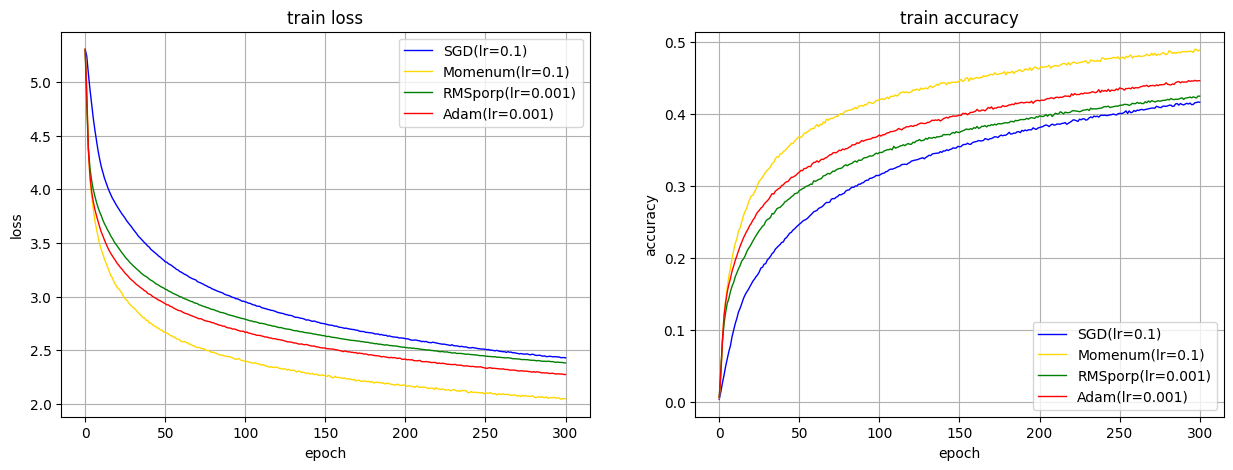

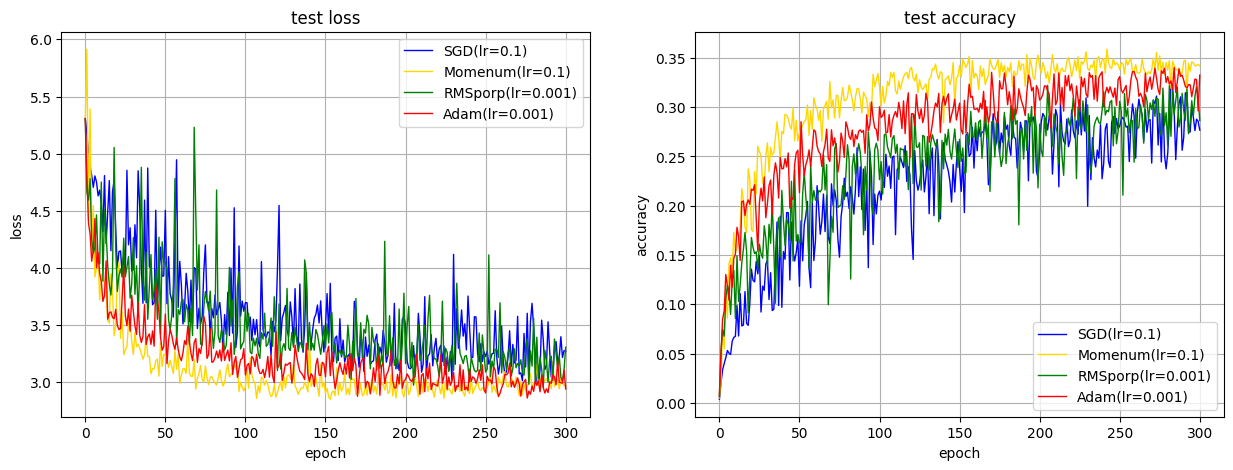

In [168]:
fig = plt.figure(figsize = (15, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(A_SGD_train_loss_history, label = "SGD(lr=0.1)", color = "blue", linewidth=1)
ax.plot(A_Momentum_train_loss_history, label = "Momenum(lr=0.1)", color = "gold", linewidth=1)
ax.plot(C_RMSporp_train_loss_history, label = "RMSporp(lr=0.001)", color = "green", linewidth=1)
ax.plot(C_Adam_train_loss_history, label = "Adam(lr=0.001)", color = "red", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(A_SGD_train_accuracy_history, label = "SGD(lr=0.1)", color = "blue", linewidth=1)
ax.plot(A_Momentum_train_accuracy_history, label = "Momenum(lr=0.1)", color = "gold", linewidth=1)
ax.plot(C_RMSporp_train_accuracy_history, label = "RMSporp(lr=0.001)", color = "green", linewidth=1)
ax.plot(C_Adam_train_accuracy_history, label = "Adam(lr=0.001)", color = "red", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()


fig = plt.figure(figsize = (15, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(A_SGD_test_loss_history, label = "SGD(lr=0.1)", color = "blue", linewidth=1)
ax.plot(A_Momentum_test_loss_history, label = "Momenum(lr=0.1)", color = "gold", linewidth=1)
ax.plot(C_RMSporp_test_loss_history, label = "RMSporp(lr=0.001)", color = "green", linewidth=1)
ax.plot(C_Adam_test_loss_history, label = "Adam(lr=0.001)", color = "red", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(A_SGD_test_accuracy_history, label = "SGD(lr=0.1)", color = "blue", linewidth=1)
ax.plot(A_Momentum_test_accuracy_history, label = "Momenum(lr=0.1)", color = "gold", linewidth=1)
ax.plot(C_RMSporp_test_accuracy_history, label = "RMSporp(lr=0.001)", color = "green", linewidth=1)
ax.plot(C_Adam_test_accuracy_history, label = "Adam(lr=0.001)", color = "red", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()